<a href="https://colab.research.google.com/github/Arij0106/Data_Analysis-Rgression-and-Time-Series-analyses/blob/main/Level_2_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1 :Regression Analysis

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [7]:
url = "https://raw.githubusercontent.com/Arij0106/Data_Analysis-Rgression-and-Time-Series-analyses/refs/heads/main/stockprices.csv"
df = pd.read_csv(url)

In [8]:
df.head(11)

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391
5,ABT,2014-01-02,38.0900,38.4000,38.0000,38.2300,4967472
6,ACN,2014-01-02,81.5000,81.9200,81.0900,81.1300,2405384
7,ADBE,2014-01-02,59.0600,59.5300,58.9400,59.2900,2746370
8,ADI,2014-01-02,49.5200,49.7500,49.0400,49.2800,2799092
9,ADM,2014-01-02,43.2200,43.2900,42.7900,42.9900,2753765


In [9]:
X = df[['open', 'high', 'low', 'volume']]
y = df['close']


In [10]:
df.isnull().sum()

,0
symbol,0
date,0
open,11
high,8
low,8
close,0
volume,0


In [11]:
df=df.dropna()

In [12]:
X = df[['open', 'high', 'low', 'volume']]
y = df['close']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


In [14]:
print("--- Évaluation du Modèle ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²): {r2:.4f}\n")

print("--- Interprétation des Coefficients ---")
print(f"Intercept: {model.intercept_:.4f}")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature.title()}: {coef:.6f}")

--- Évaluation du Modèle ---
Mean Squared Error (MSE): 0.5160
R-squared (R²): 1.0000

--- Interprétation des Coefficients ---
Intercept: -0.0079
Open: -0.538093
High: 0.787251
Low: 0.750968
Volume: -0.000000


# Task 2: Time series analysis

In [15]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


In [16]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 10)

In [17]:
cols_to_clean = ['open', 'high', 'low', 'close', 'volume']
for col in cols_to_clean:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=['date', 'close'])

In [18]:
symbol_df = df[df['symbol'] == 'AAPL'].copy()

In [19]:
symbol_df['date'] = pd.to_datetime(symbol_df['date'])
symbol_df = symbol_df.sort_values(by='date')
symbol_df.set_index('date', inplace=True)

In [20]:
ts_data = symbol_df['close'].resample('B').ffill().dropna()


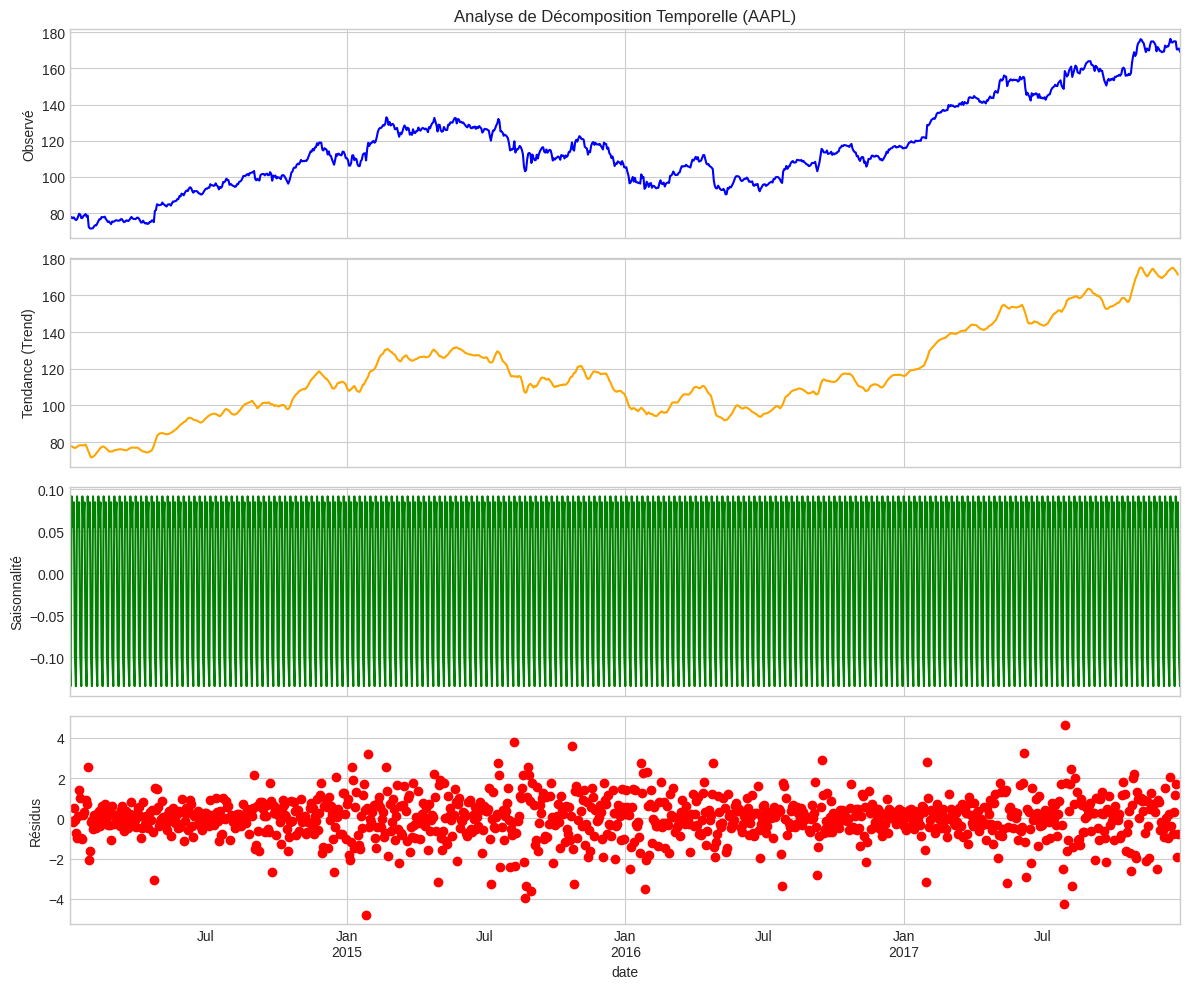

In [21]:
decomposition = seasonal_decompose(ts_data, model='additive', period=5)
fig, axes = plt.subplots(4, 1, sharex=True)
decomposition.observed.plot(ax=axes[0], color='blue', title='Analyse de Décomposition Temporelle (AAPL)')
axes[0].set_ylabel('Observé')
decomposition.trend.plot(ax=axes[1], color='orange')
axes[1].set_ylabel('Tendance (Trend)')
decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_ylabel('Saisonnalité')
decomposition.resid.plot(ax=axes[3], color='red', style='o')
axes[3].set_ylabel('Résidus')
plt.tight_layout()
plt.show()


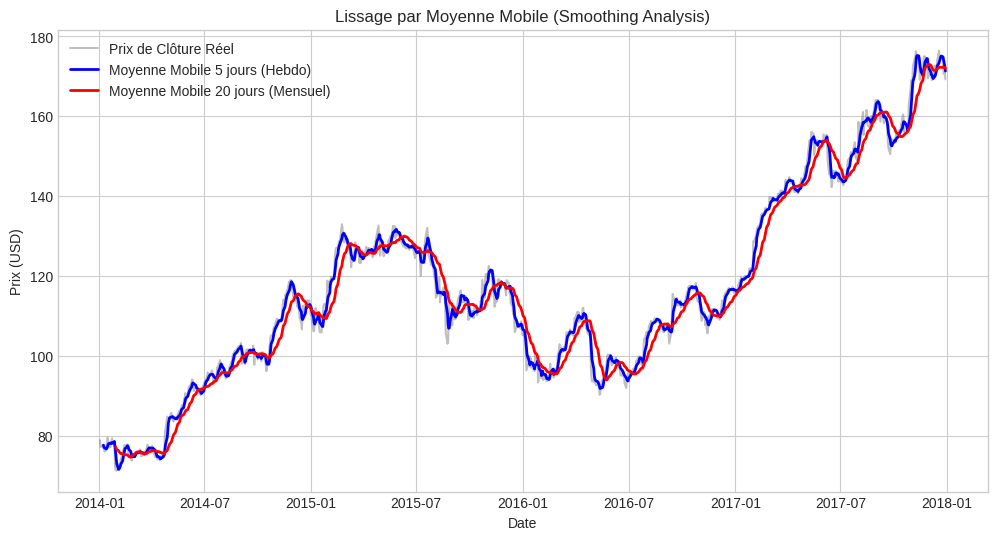

In [22]:
plt.figure(figsize=(12, 6))
ts_data_ma5 = ts_data.rolling(window=5).mean()
ts_data_ma20 = ts_data.rolling(window=20).mean()
plt.plot(ts_data.index, ts_data, label='Prix de Clôture Réel', alpha=0.5, color='gray')
plt.plot(ts_data_ma5.index, ts_data_ma5, label='Moyenne Mobile 5 jours (Hebdo)', linewidth=2, color='blue')
plt.plot(ts_data_ma20.index, ts_data_ma20, label='Moyenne Mobile 20 jours (Mensuel)', linewidth=2, color='red')
plt.title('Lissage par Moyenne Mobile (Smoothing Analysis)')
plt.xlabel('Date')
plt.ylabel('Prix (USD)')
plt.legend()
plt.show()